# Transient collision with an old ice reservoir

This notebook tests the smallest kinematic version of hypothesis 1. A Pleistocene ice packet receives a finite velocity pulse upstream of a nearly stagnant old reservoir. The calculation asks whether smooth, incompressible deformation can close a 6 km-wide intervening age interval while conserving ice mass. A uniform, time-invariant velocity is the negative control.

The calculation uses Firedrake to construct and project the velocity field. Icepack is available in the same environment, but a stress-balance solve is deliberately omitted because the velocity anomaly is the hypothesis being tested, rather than a consequence of a specified basal law.

## Model and assumptions

Coordinates $x$ and $z$ are measured in km and time is measured in years. The velocity is the curl of a streamfunction,

$$\psi(x,z,t)=U_0z+a(t)\,\Delta U\,zS(x), \qquad (u,w)=(\partial_z\psi,-\partial_x\psi).$$

The velocity is therefore divergence-free before finite-element projection. The smooth cubic $S$ decreases from one at $x=22$ km to zero at $x=28$ km. The pulse $a(t)$ ramps up from 50 to 100 yr, remains constant until 350 yr, and ramps down by 400 yr. Its time integral is 300 yr. The background speed is $U_0=0.5$ m/yr and the pulse is $\Delta U=30$ m/yr. The downstream reservoir therefore moves only 0.25 km during the 500 yr calculation, whereas unobstructed upstream ice would move 9.25 km.

Material markers obey $d\mathbf{x}/dt=\mathbf{u}$. Their ages are labels, not a prognostic age solution: each label would increase by only 0.0005 Ma during this experiment. The initial labels vary from 0.5 Ma upstream to 5 Ma downstream. Thus the model tests deformation of an existing age distribution. It does not explain how 5 Ma ice was preserved or how the initial age distribution formed.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import icepack
from firedrake import (
    RectangleMesh, SpatialCoordinate, VectorFunctionSpace, as_vector,
    assemble, conditional, div, dx, grad, inner, project, sqrt,
)

plt.style.use("seaborn-v0_8-whitegrid")
print(f"Icepack imported from {icepack.__file__}")

Icepack imported from /home/firedrake/firedrake/lib/python3.12/site-packages/icepack/__init__.py


In [2]:
L_X, H_COMPUTATIONAL = 40.0, 8.0  # km; the tall domain permits free-surface thickening
U_0, DELTA_U = 0.0005, 0.030     # km/yr
X_YOUNG, X_OLD = 22.0, 28.0      # edges of the initial transition, km
T_END, DT = 500.0, 1.0           # yr
AGE_YOUNG, AGE_OLD = 0.5, 5.0    # Ma; material labels only

def pulse(t):
    """Finite-duration pulse with an integral of 300 yr."""
    if t < 50.0 or t >= 400.0:
        return 0.0
    if t < 100.0:
        return np.sin(np.pi * (t - 50.0) / 100.0) ** 2
    if t < 350.0:
        return 1.0
    return np.cos(np.pi * (t - 350.0) / 100.0) ** 2

def build_model(nx):
    """Project the streamfunction curl into a quadratic Firedrake space."""
    nz = nx // 5  # square 0.5 km or 0.25 km cells
    mesh = RectangleMesh(nx, nz, L_X, H_COMPUTATIONAL)
    x, z = SpatialCoordinate(mesh)
    V = VectorFunctionSpace(mesh, "CG", 2)
    q = (x - X_YOUNG) / (X_OLD - X_YOUNG)
    S = conditional(
        x <= X_YOUNG, 1.0,
        conditional(x >= X_OLD, 0.0, 1.0 - 3.0 * q**2 + 2.0 * q**3),
    )
    psi_background = U_0 * z
    psi_event = DELTA_U * z * S
    curl = lambda psi: as_vector((grad(psi)[1], -grad(psi)[0]))
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        u_background = project(curl(psi_background), V)
        u_event = project(curl(psi_event), V)

    # Projection slightly perturbs exact incompressibility; report its relative size.
    div_ratio = float(
        sqrt(assemble(div(u_event) ** 2 * dx))
        / sqrt(assemble(inner(grad(u_event), grad(u_event)) * dx))
    )

    # Sample the Firedrake functions on the native grid for marker integration.
    gx = np.linspace(0.0, L_X, nx + 1)
    gz = np.linspace(0.0, H_COMPUTATIONAL, nz + 1)
    X, Z = np.meshgrid(gx, gz)
    sample_points = np.column_stack((X.ravel(), Z.ravel()))
    background = np.asarray(u_background.at(sample_points, tolerance=1.0e-10))
    event = np.asarray(u_event.at(sample_points, tolerance=1.0e-10))
    shape = (nz + 1, nx + 1, 2)
    return {
        "nx": nx, "nz": nz, "gx": gx, "gz": gz,
        "background": background.reshape(shape),
        "event": event.reshape(shape), "div_ratio": div_ratio,
    }

def interpolate_velocity(model, points, amplitude):
    """Bilinearly sample the projected Firedrake velocity."""
    gx, gz = model["gx"], model["gz"]
    if (points[:, 0].min() < gx[0] or points[:, 0].max() > gx[-1]
            or points[:, 1].min() < gz[0] or points[:, 1].max() > gz[-1]):
        raise ValueError("A marker left the computational domain")
    dxg, dzg = gx[1] - gx[0], gz[1] - gz[0]
    ix = np.clip(np.floor(points[:, 0] / dxg).astype(int), 0, len(gx) - 2)
    iz = np.clip(np.floor(points[:, 1] / dzg).astype(int), 0, len(gz) - 2)
    tx = (points[:, 0] - gx[ix]) / dxg
    tz = (points[:, 1] - gz[iz]) / dzg

    def bilinear(values):
        return (
            ((1 - tx) * (1 - tz))[:, None] * values[iz, ix]
            + (tx * (1 - tz))[:, None] * values[iz, ix + 1]
            + ((1 - tx) * tz)[:, None] * values[iz + 1, ix]
            + (tx * tz)[:, None] * values[iz + 1, ix + 1]
        )

    return bilinear(model["background"]) + amplitude * bilinear(model["event"])

def advect(model, initial, transient=True, keep_history=False):
    """Second-order midpoint integration of material markers."""
    points = initial.copy()
    history = [points.copy()] if keep_history else None
    for step in range(int(T_END / DT)):
        t = step * DT
        a0 = pulse(t) if transient else 0.0
        ah = pulse(t + 0.5 * DT) if transient else 0.0
        k1 = interpolate_velocity(model, points, a0)
        midpoint = points + 0.5 * DT * k1
        k2 = interpolate_velocity(model, midpoint, ah)
        points += DT * k2
        if keep_history:
            history.append(points.copy())
    return points, None if history is None else np.asarray(history)

## Material-marker experiment

The marker grid initially occupies a 0.9 km-thick flow band. Horizontal rows are initially flat layer markers. Marker columns have equal age labels: Pleistocene ice lies upstream of 22 km, 5 Ma ice lies downstream of 28 km, and the intervening labels vary linearly. A smooth deformation must retain those intermediate labels because material trajectories cannot terminate inside the domain.

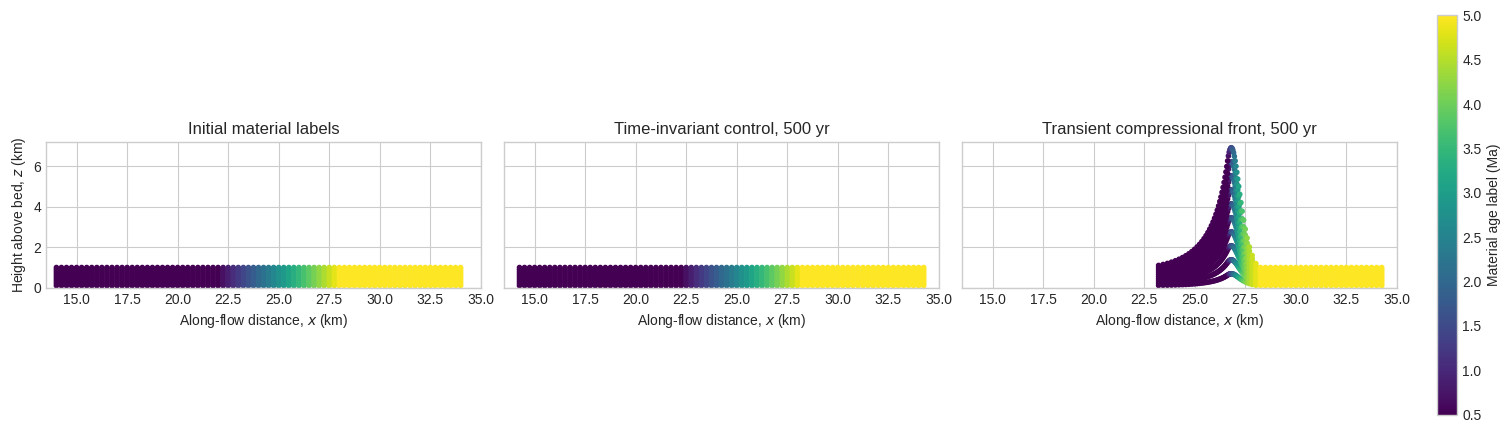

In [3]:
marker_x = np.linspace(14.0, 34.0, 81)
marker_z = np.linspace(0.1, 1.0, 10)
MX, MZ = np.meshgrid(marker_x, marker_z)
initial = np.column_stack((MX.ravel(), MZ.ravel()))
marker_shape = MX.shape
age_labels = np.interp(initial[:, 0], [X_YOUNG, X_OLD], [AGE_YOUNG, AGE_OLD])

coarse_model = build_model(80)
fine_model = build_model(160)
control, _ = advect(fine_model, initial, transient=False)
event_coarse, _ = advect(coarse_model, initial, transient=True)
event_fine, _ = advect(fine_model, initial, transient=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5.2), sharex=True, sharey=True, constrained_layout=True)
states = [(initial, "Initial material labels"),
          (control, "Time-invariant control, 500 yr"),
          (event_fine, "Transient compressional front, 500 yr")]
for ax, (points, title) in zip(axes, states):
    grid = points.reshape(*marker_shape, 2)
    for row in grid:
        ax.plot(row[:, 0], row[:, 1], color="0.68", lw=0.6, zorder=1)
    scatter = ax.scatter(points[:, 0], points[:, 1], c=age_labels, s=9,
                         cmap="viridis", vmin=AGE_YOUNG, vmax=AGE_OLD, zorder=2)
    ax.set_title(title)
    ax.set_xlabel("Along-flow distance, $x$ (km)")
    ax.set_xlim(13.5, 35.0)
    ax.set_ylim(0.0, 7.2)
    ax.set_aspect("equal")
axes[0].set_ylabel("Height above bed, $z$ (km)")
cbar = fig.colorbar(scatter, ax=axes, shrink=0.78, pad=0.02)
cbar.set_label("Material age label (Ma)")
plt.show()

**Figure 1. Material response to steady and transient flow.** The steady control translates the labels without deforming them. The transient pulse shortens the age transition and rotates the initially horizontal marker layers upward. Intermediate-age material remains between the selected young and old columns; it is stretched vertically rather than removed. The several-kilometer modeled thickening is a warning that this strong smooth-flow event is not a plausible reconstruction of present Allan Hills geometry.

In [4]:
def gridded_area(points, shape):
    """Sum quadrilateral marker-cell areas as a mass proxy for unit density."""
    grid = points.reshape(*shape, 2)
    total = 0.0
    for j in range(shape[0] - 1):
        for i in range(shape[1] - 1):
            quad = np.array([grid[j, i], grid[j, i + 1],
                             grid[j + 1, i + 1], grid[j + 1, i]])
            xq, zq = quad[:, 0], quad[:, 1]
            total += 0.5 * abs(np.dot(xq, np.roll(zq, -1))
                               - np.dot(zq, np.roll(xq, -1)))
    return total

def diagnostics(model, final, transient=True):
    young_index = np.argmin((initial[:, 0] - X_YOUNG) ** 2 + (initial[:, 1] - 0.5) ** 2)
    old_index = np.argmin((initial[:, 0] - X_OLD) ** 2 + (initial[:, 1] - 0.5) ** 2)
    initial_separation = initial[old_index, 0] - initial[young_index, 0]
    final_separation = final[old_index, 0] - final[young_index, 0]
    area_0 = gridded_area(initial, marker_shape)
    area_f = gridded_area(final, marker_shape)
    return {
        "dx": L_X / model["nx"],
        "separation": final_separation,
        "shortening": 100.0 * (1.0 - final_separation / initial_separation),
        "young_displacement": final[young_index, 0] - initial[young_index, 0],
        "vertical_stretch": final[young_index, 1] / initial[young_index, 1],
        "mass_error": 100.0 * (area_f - area_0) / area_0,
        "div_ratio": 100.0 * model["div_ratio"] if transient else 0.0,
    }

coarse = diagnostics(coarse_model, event_coarse)
fine = diagnostics(fine_model, event_fine)
steady = diagnostics(fine_model, control, transient=False)

print("case       dx (km)  final gap (km)  shortening (%)  young dx (km)  z stretch  mass error (%)  div/grad (%)")
for name, values in [("steady", steady), ("coarse", coarse), ("fine", fine)]:
    print(f"{name:8s} {values['dx']:8.3f} {values['separation']:15.4f}"
          f" {values['shortening']:15.2f} {values['young_displacement']:14.3f}"
          f" {values['vertical_stretch']:10.2f} {values['mass_error']:15.4f}"
          f" {values['div_ratio']:12.4f}")
print(f"\nFactor-of-two resolution change in final gap: "
      f"{100 * abs(coarse['separation'] - fine['separation']) / fine['separation']:.3f}%")

case       dx (km)  final gap (km)  shortening (%)  young dx (km)  z stretch  mass error (%)  div/grad (%)
steady      0.250          6.0000            0.00          0.250       1.00          0.0000       0.0000
coarse      0.500          1.6235           72.94          4.626       6.22         -0.1820       0.1563
fine        0.250          1.6256           72.91          4.624       6.27          0.0180       0.0394

Factor-of-two resolution change in final gap: 0.127%


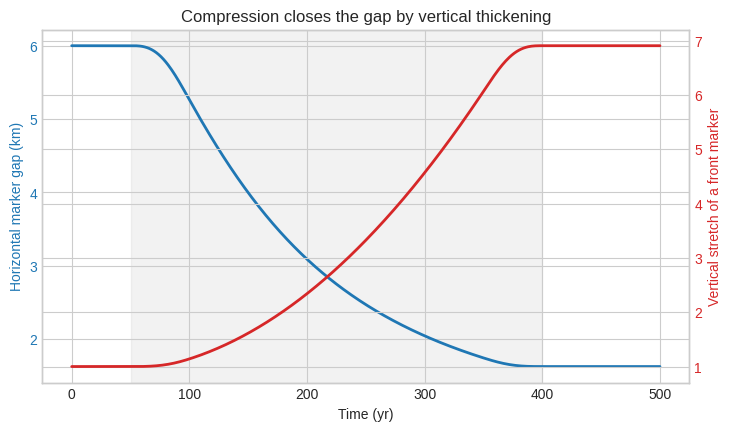

In [5]:
probe_initial = np.array([[X_YOUNG, 0.5], [X_OLD, 0.5], [23.0, 1.0]])
_, probe_history = advect(fine_model, probe_initial, transient=True, keep_history=True)
times = np.arange(probe_history.shape[0]) * DT
gap_history = probe_history[:, 1, 0] - probe_history[:, 0, 0]
stretch_history = probe_history[:, 2, 1] / probe_initial[2, 1]

fig, ax1 = plt.subplots(figsize=(7.2, 4.2), constrained_layout=True)
ax1.plot(times, gap_history, color="tab:blue", lw=2, label="young-old marker gap")
ax1.set_xlabel("Time (yr)")
ax1.set_ylabel("Horizontal marker gap (km)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax2 = ax1.twinx()
ax2.plot(times, stretch_history, color="tab:red", lw=2, label="vertical stretch")
ax2.set_ylabel("Vertical stretch of a front marker", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax1.axvspan(50, 400, color="0.8", alpha=0.25, label="velocity-pulse interval")
ax1.set_title("Compression closes the gap by vertical thickening")
plt.show()

**Figure 2. Collision kinematics.** The gap closes only while the pulse is active. Incompressibility links horizontal shortening to vertical stretching, so the same deformation that narrows the age transition thickens and rotates the material layers.

## Interpretation

This strong event displaces the leading young marker by several kilometers and shortens the selected 6 km age interval substantially. Nevertheless, the final interval remains kilometer-scale, and the front thickens by several times its initial height. Because a smooth velocity field preserves the ordering of material trajectories, it cannot delete the intermediate ages. Reducing a 6 km interval to an illustrative 10 m contact by smooth plane strain would require a shortening strain $\ln(600)\approx6.4$ and a compensating vertical stretch near 600. Faulting, erosion, a pre-existing unconformity, or transport around the modeled plane would be needed to avoid that consequence.

The factor-of-two mesh comparison tests the finite-element representation of the front, and the marker-cell area tests mass conservation. Agreement between the two meshes establishes that the broad transition and large thickening are not consequences of the chosen spatial resolution. It does not establish that a 30 m/yr pulse occurred at Allan Hills.

This toy model can therefore establish displacement, shortening, and mass-balance requirements for a collision. It cannot predict the pulse from ice rheology, represent fractures or thrust faults, resolve three-dimensional bypass flow, create the initial 5 Ma reservoir, or evaluate isotope diffusion. The next useful calculation would add either a material discontinuity (scour or fault) or a three-dimensional escape path, rather than a more elaborate smooth constitutive law.